<a href="https://colab.research.google.com/github/jonasbuc/Colab/blob/Linear_Regression.ipynb/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Ensure that we use Python 3.7 or above:

In [2]:
import sys

assert sys.version_info >= (3, 7)

### Ensure that we use at least Scikit-Learn 1.0.1

In [3]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

### Let us set up the fonts in mathplotlib

In [1]:
import matplotlib.pyplot as plt

plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

### Import important libraries 'numpy' and 'pandas'

In [4]:
import numpy as np
import pandas as pd

# Make reference to life satifaction data file

In [5]:
datafile = "https://github.com/ageron/data/raw/main/lifesat/lifesat.csv"

##Try with this one later
##datafile = "https://raw.githubusercontent.com/jpandersen61/Machine-Learning/main/InjuredandkilledintrafikDK.csv"

### Excercise(s):

Try viewing this file in your internet browser

### Load the data file

In [6]:
lifesat = pd.read_csv(datafile)


### Excercise(s)

1. Make a new code cell below and evaluate 'lifesat'

In [20]:
print("\n" + "=" * 50)
print("EXERCISE: Evaluating the lifesat dataset")
print("=" * 50)
print("lifesat =")
print(lifesat)


EXERCISE: Evaluating the lifesat dataset
lifesat =
           Country  GDP per capita (USD)  Life satisfaction
0           Russia          26456.387938                5.8
1           Greece          27287.083401                5.4
2           Turkey          28384.987785                5.5
3           Latvia          29932.493910                5.9
4          Hungary          31007.768407                5.6
5         Portugal          32181.154537                5.4
6           Poland          32238.157259                6.1
7          Estonia          35638.421351                5.7
8            Spain          36215.447591                6.3
9         Slovenia          36547.738956                5.9
10       Lithuania          36732.034744                5.9
11          Israel          38341.307570                7.2
12           Italy          38992.148381                6.0
13  United Kingdom          41627.129269                6.8
14          France          42025.617373        

2. Get some information about the kind of data structure, that life satisfaction data is store in. Usefuk to know when using the data afterwards in Python: Make a new code cell below and evaluate 'type(lifesat)'

In [21]:
print("\n" + "=" * 50)
print("EXERCISE: Data structure information")
print("=" * 50)
print(f"type(lifesat) = {type(lifesat)}")
print(f"Shape: {lifesat.shape}")
print(f"Columns: {list(lifesat.columns)}")
print("\nData info:")
lifesat.info()
print("\nData description:")
print(lifesat.describe())


EXERCISE: Data structure information
type(lifesat) = <class 'pandas.core.frame.DataFrame'>
Shape: (27, 3)
Columns: ['Country', 'GDP per capita (USD)', 'Life satisfaction']

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               27 non-null     object 
 1   GDP per capita (USD)  27 non-null     float64
 2   Life satisfaction     27 non-null     float64
dtypes: float64(2), object(1)
memory usage: 780.0+ bytes

Data description:
       GDP per capita (USD)  Life satisfaction
count             27.000000          27.000000
mean           41564.521771           6.566667
std             9631.452319           0.765607
min            26456.387938           5.400000
25%            33938.289305           5.900000
50%            41627.129269           6.800000
75%            49690.580269           7.300000
max   

### Extract the learning set 'X' and its labels 'y'

In [7]:
X = lifesat[["GDP per capita (USD)"]].values
y = lifesat[["Life satisfaction"]].values



### Exercises:

In [14]:
print("\n" + "=" * 50)
print("EXERCISE: Evaluating X (features)")
print("=" * 50)
print("X =")
print(X)
print(f"X shape: {X.shape}")
print(f"X data type: {X.dtype}")


EXERCISE: Evaluating X (features)
X =
[23500.         23539.03903904 23578.07807808 23617.11711712
 23656.15615616 23695.1951952  23734.23423423 23773.27327327
 23812.31231231 23851.35135135 23890.39039039 23929.42942943
 23968.46846847 24007.50750751 24046.54654655 24085.58558559
 24124.62462462 24163.66366366 24202.7027027  24241.74174174
 24280.78078078 24319.81981982 24358.85885886 24397.8978979
 24436.93693694 24475.97597598 24515.01501502 24554.05405405
 24593.09309309 24632.13213213 24671.17117117 24710.21021021
 24749.24924925 24788.28828829 24827.32732733 24866.36636637
 24905.40540541 24944.44444444 24983.48348348 25022.52252252
 25061.56156156 25100.6006006  25139.63963964 25178.67867868
 25217.71771772 25256.75675676 25295.7957958  25334.83483483
 25373.87387387 25412.91291291 25451.95195195 25490.99099099
 25530.03003003 25569.06906907 25608.10810811 25647.14714715
 25686.18618619 25725.22522523 25764.26426426 25803.3033033
 25842.34234234 25881.38138138 25920.42042042 25

Make a new code cell below and evaluate 'X'





Make a new code cell below and evaluate 'y'

In [15]:
print("\n" + "=" * 50)
print("EXERCISE: Evaluating y (labels)")
print("=" * 50)
print("y =")
print(y)
print(f"y shape: {y.shape}")
print(f"y data type: {y.dtype}")


EXERCISE: Evaluating y (labels)
y =
[[5.8]
 [5.4]
 [5.5]
 [5.9]
 [5.6]
 [5.4]
 [6.1]
 [5.7]
 [6.3]
 [5.9]
 [5.9]
 [7.2]
 [6. ]
 [6.8]
 [6.5]
 [7.3]
 [7.4]
 [7.6]
 [6.9]
 [7.3]
 [7.3]
 [7. ]
 [7.1]
 [7.5]
 [7.4]
 [7.6]
 [6.9]]
y shape: (27, 1)
y data type: float64


### Let us plot the life satisfaction data and introduce a model


8. Plotting the data...


<Figure size 800x600 with 0 Axes>

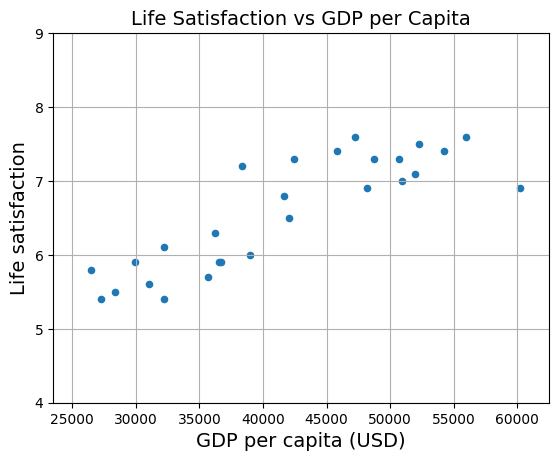

✓ Basic scatter plot created


In [23]:
print("\n8. Plotting the data...")
plt.figure(figsize=(8, 6))
lifesat.plot(kind='scatter', grid=True,
             x="GDP per capita (USD)", y="Life satisfaction")
plt.axis([23_500, 62_500, 4, 9])
plt.title("Life Satisfaction vs GDP per Capita")
plt.show()
print("✓ Basic scatter plot created")

### Excercise(s):

Define various 't0' and 't1' (thetas) and observe how it affects our model


EXERCISE: Manual model parameters
Using θ0 = 3.75, θ1 = 6.78e-05


<Figure size 800x600 with 0 Axes>

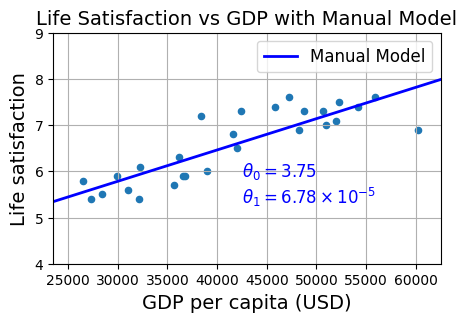

✓ Manual model visualization created


In [22]:
print("\n" + "=" * 50)
print("EXERCISE: Manual model parameters")
print("=" * 50)

t0, t1 = 3.75, 6.78e-05
print(f"Using θ0 = {t0}, θ1 = {t1}")

from sklearn import linear_model
min_gdp = 23_500
max_gdp = 62_500
min_life_sat = 4
max_life_sat = 9

plt.figure(figsize=(8, 6))
lifesat.plot(kind='scatter', figsize=(5, 3), grid=True,
             x="GDP per capita (USD)", y="Life satisfaction")

X_line = np.linspace(min_gdp, max_gdp, 1000)
plt.plot(X_line, t0 + t1 * X_line, "b", linewidth=2, label="Manual Model")

plt.text(max_gdp - 20_000, min_life_sat + 1.9,
         fr"$\theta_0 = {t0:.2f}$", color="b")
plt.text(max_gdp - 20_000, min_life_sat + 1.3,
         fr"$\theta_1 = {t1 * 1e5:.2f} \times 10^{{-5}}$", color="b")

plt.axis([min_gdp, max_gdp, min_life_sat, max_life_sat])
plt.title("Life Satisfaction vs GDP with Manual Model")
plt.legend()
plt.show()
print("✓ Manual model visualization created")

### Establish the model

In [10]:
from sklearn import linear_model

X_features = lifesat[["GDP per capita (USD)"]]
y_labels = lifesat[["Life satisfaction"]]

lin1 = linear_model.LinearRegression()
lin1.fit(X_features, y_labels)

t0, t1 = lin1.intercept_[0], lin1.coef_[0][0]
print(f"θ0={t0:.2f}, θ1={t1:.2e}")

θ0=3.75, θ1=6.78e-05


In [11]:
X_pred = 40000
y_pred = lin1.predict([[X_pred]])[0,0]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [12]:
y_pred

np.float64(6.4606093051133975)

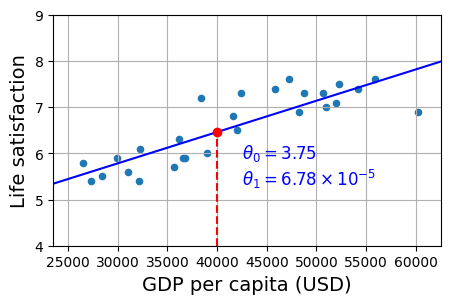

In [13]:
from sklearn import linear_model
min_gdp = 23_500
max_gdp = 62_500
min_life_sat = 4
max_life_sat = 9

lifesat.plot(kind='scatter', figsize=(5, 3), grid=True,
                   x="GDP per capita (USD)", y="Life satisfaction")

X = np.linspace(min_gdp, max_gdp, 1000)
plt.plot(X, t0 + t1 * X, "b")

plt.text(max_gdp - 20_000, min_life_sat + 1.9,
         fr"$\theta_0 = {t0:.2f}$", color="b")
plt.text(max_gdp - 20_000, min_life_sat + 1.3,
         fr"$\theta_1 = {t1 * 1e5:.2f} \times 10^{{-5}}$", color="b")

plt.axis([min_gdp, max_gdp, min_life_sat, max_life_sat])

plt.plot([X_pred, X_pred],
         [min_life_sat, y_pred], "r--")
plt.plot(X_pred, y_pred, "ro")

plt.show()

### Excercise(s):


1. Try with another dataset https://raw.githubusercontent.com/jpandersen61/Machine-Learning/main/InjuredandkilledintrafikDK.csv

In [19]:
print("\n" + "=" * 50)
print("EXERCISE: Alternative Dataset - Danish Traffic Data")
print("=" * 50)

try:
    traffic_datafile = "https://raw.githubusercontent.com/jpandersen61/Machine-Learning/main/InjuredandkilledintrafikDK.csv"
    print(f"Loading traffic data from: {traffic_datafile}")
    traffic_data = pd.read_csv(traffic_datafile)
    print("✓ Danish traffic data loaded successfully")
    print(f"Shape: {traffic_data.shape}")
    print("\nFirst few rows:")
    print(traffic_data.head())
    print("\nColumns:")
    print(list(traffic_data.columns))
except Exception as e:
    print(f"Could not load traffic data: {e}")


EXERCISE: Alternative Dataset - Danish Traffic Data
Loading traffic data from: https://raw.githubusercontent.com/jpandersen61/Machine-Learning/main/InjuredandkilledintrafikDK.csv
✓ Danish traffic data loaded successfully
Shape: (22, 2)

First few rows:
   year  quantity
0  2001      8896
1  2002      9254
2  2003      8844
3  2004      7915
4  2005      6919

Columns:
['year', 'quantity']


### Questions

1. How would you define Machine Learning?


     "Machine Learning is a field of artificial intelligence that enables computers to learn and make decisions from data without being explicitly programmed for every specific task. It uses algorithms to identify patterns in data and make predictions or decisions based on those patterns."),


Write your answer here

2. Can you name four types of problems where it shines?

     "1. Image Recognition (e.g., medical diagnosis, autonomous vehicles)\n2. Natural Language Processing (e.g., translation, sentiment analysis)\n3. Recommendation Systems (e.g., Netflix, Amazon)\n4. Predictive Analytics (e.g., stock prices, weather forecasting)"),


Write your answer here

3. What is a labeled training set?

     "A labeled training set is a dataset where each example includes both input features and the correct output (label). For example, in email spam detection, each email (input) would be labeled as 'spam' or 'not spam' (output). This allows supervised learning algorithms to learn the relationship between inputs and outputs."),


Write your answer here

4. What are the two most common supervised tasks?

     "1. Classification: Predicting discrete categories or classes (e.g., spam/not spam, cat/dog)\n2. Regression: Predicting continuous numerical values (e.g., house prices, temperature)"),


Write your answer here

5. Can you name four common unsupervised tasks?

     "1. Clustering: Grouping similar data points together\n2. Dimensionality Reduction: Reducing the number of features while preserving important information\n3. Anomaly Detection: Identifying unusual patterns or outliers\n4. Association Rule Learning: Finding relationships between different variables"),


Write your answer here

6. What type of Machine Learning algorithm would you use to allow
a robot to walk in various unknown terrains?


     "Reinforcement Learning. The robot would learn through trial and error, receiving rewards for successful steps and penalties for falls, gradually improving its walking strategy for different terrains through interaction with the environment."),


Write your answer here

7. What type of algorithm would you use to segment your customers
into multiple groups?

     "Clustering algorithms (unsupervised learning), such as K-means, hierarchical clustering, or DBSCAN. These algorithms group customers based on similarities in their behavior, demographics, or purchasing patterns without predefined labels."),


Write your answer here

8. Would you frame the problem of spam detection as a supervised
learning problem or an unsupervised learning problem?

     "Supervised learning problem. Spam detection typically uses labeled training data where emails are already classified as 'spam' or 'not spam' to train the algorithm to recognize patterns that distinguish spam from legitimate emails."),


Write your answer here

9. What is an online learning system?


     "An online learning system learns incrementally from new data as it arrives, rather than being trained once on a fixed dataset. It can adapt to changing patterns and handle streaming data, making it suitable for applications where data arrives continuously."),


Write your answer here

10. What is out-of-core learning?

     "Out-of-core learning is used when the dataset is too large to fit in memory. The algorithm processes the data in small batches or chunks, loading only a portion at a time, making it possible to train on datasets larger than available RAM."),


Write your answer here

11. What type of learning algorithm relies on a similarity measure to
make predictions?

     "Instance-based learning algorithms (also called memory-based learning), such as k-Nearest Neighbors (k-NN). These algorithms store training examples and make predictions based on the similarity to stored instances."),


Write your answer here

12. What is the difference between a model parameter and a learning
algorithm’s hyperparameter?

     "Model parameters are learned by the algorithm from training data (e.g., weights in linear regression). Hyperparameters are configuration settings chosen before training that control the learning process (e.g., learning rate, number of hidden layers)."),


Write your answer here

13. What do model-based learning algorithms search for? What is the
most common strategy they use to succeed? How do they make
predictions?

     "They search for optimal parameter values for a mathematical model. The most common strategy is to minimize a cost function that measures prediction errors. They make predictions by applying the learned model with optimized parameters to new data."),


Write your answer here

14. Can you name four of the main challenges in Machine Learning?

     "1. Insufficient training data: Not having enough examples to learn patterns\n2. Poor data quality: Noisy, inconsistent, or irrelevant features\n3. Overfitting: Model memorizes training data but fails on new data\n4. Underfitting: Model is too simple to capture underlying patterns")


Write your answer here